In [1]:
import pandas as pd

df = pd.read_csv("fighter_styles_clean.csv")
print(df.shape)
df.head()

(2514, 21)


,Fighter_Name,Stance,DOB,Wins,Losses,Draws,SLpM,Str_Acc,SApM,Str_Def,...,TD_Acc,TD_Def,Sub_Avg,Height_in,Reach_in,Weight_lbs,Ape_Index,Weight_Class,Cluster,Fighting_Style
0,Nariman Abbasov,Orthodox,1994-02-01,28,4,0,3.00,0.20,5.67,0.46,...,0.00,0.66,0.0,68,66.0,155.0,-2.0,Lightweight,2,Defensive
1,Darion Abbey,Orthodox,1993-02-25,9,5,0,8.44,0.50,14.06,0.28,...,0.00,0.00,0.0,74,80.0,265.0,6.0,Heavyweight,2,Defensive
2,Hamdy Abdelwahab,Southpaw,1993-01-22,7,1,0,4.27,0.55,3.67,0.51,...,0.65,1.00,0.0,74,72.0,265.0,-2.0,Heavyweight,3,Balanced
3,Mansur Abdul-Malik,Orthodox,1997-10-07,9,0,1,4.18,0.48,3.46,0.51,...,0.50,0.83,0.5,74,80.0,185.0,6.0,Middleweight,3,Balanced
4,Shamil Abdurakhimov,Orthodox,1981-09-02,20,8,0,2.41,0.44,3.02,0.55,...,0.23,0.45,0.1,75,76.0,235.0,1.0,Heavyweight,3,Balanced


## set features and target

In [3]:
# set features and target
features = ["Ape_Index", "Weight_lbs", "SLpM", "Str_Acc", "SApM", 
            "Str_Def", "TD_Avg", "TD_Acc", "TD_Def", "Sub_Avg"]

X = df[features]
y = df["Fighting_Style"]

print(X.shape)
print(y.value_counts())

(2514, 10)
Fighting_Style
Balanced     1074
Brawler       645
Defensive     425
Grappler      370
Name: count, dtype: int64


## split train and test

In [5]:
# split train and test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")

Training rows: 2011
Testing rows: 503


## training the decision tree

In [7]:
# training the decision tree
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

print("Dec Tree trained...")

Dec Tree trained...


## evaluate the model

In [9]:
# evaluate the model
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Balanced       0.68      0.89      0.77       206
     Brawler       0.81      0.51      0.63       130
   Defensive       0.69      0.77      0.73        86
    Grappler       0.69      0.49      0.58        81

    accuracy                           0.71       503
   macro avg       0.72      0.66      0.68       503
weighted avg       0.72      0.71      0.69       503




model is good at catching balanced fighters (0.89 recall)
best precision (0.81) for catching brawlers
decent at catching defensive fighters (0.73 f1)
grappler was weakest (0.58 F1) bc its hardest to pin down, overlaps with balanced

# visualize the tree

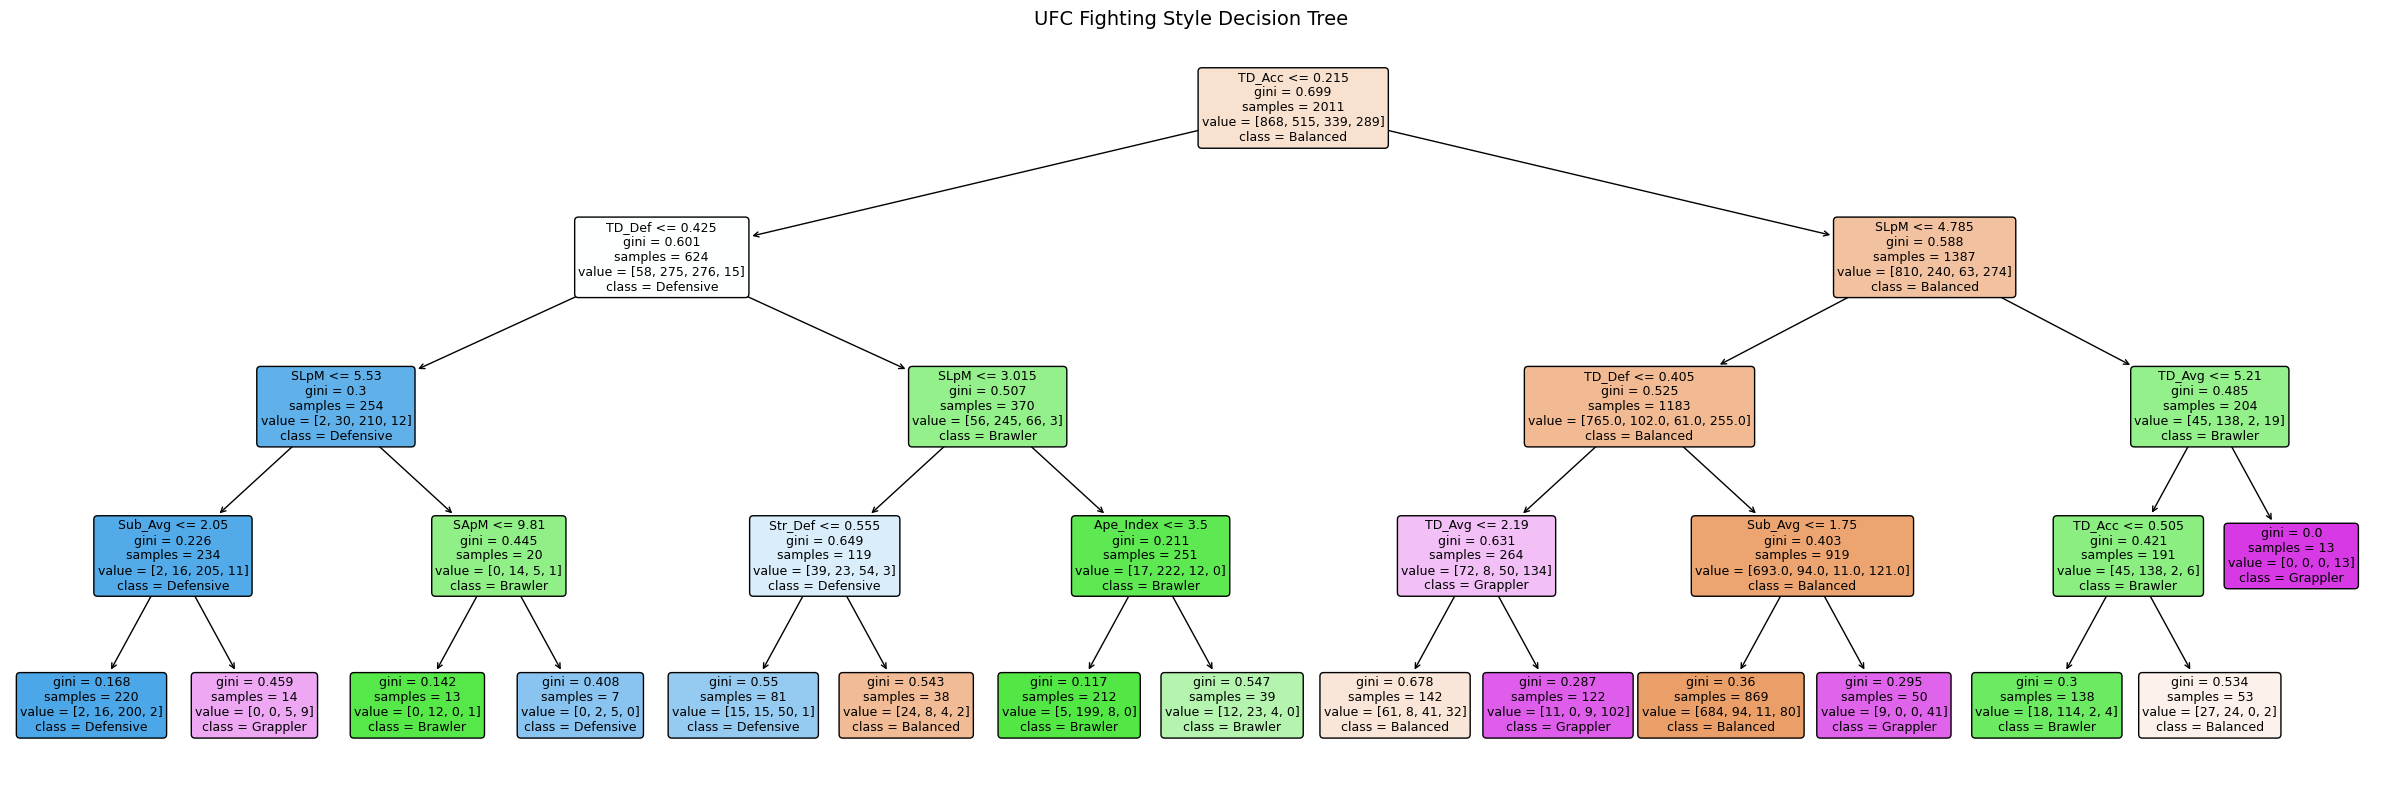

In [13]:
# visualize the tree
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(24, 8))
plot_tree(model, 
          feature_names=features, 
          class_names=model.classes_, 
          filled=True, 
          rounded=True,
          fontsize=9)
plt.title("UFC Fighting Style Decision Tree", fontsize=14)
plt.tight_layout()
plt.savefig("decision_tree.png", dpi=150, bbox_inches="tight")
plt.show()